# 4.5 Layer-Wise Feature Probing — Semantic Abstraction vs Depth

We probe **semantic abstraction across depth** in a pretrained **DenseNet-121** by extracting intermediate representations at three meaningful depths and training a **separate linear classifier (linear probe)** on each feature set. The backbone is **frozen**; only the probes are trained.

## Layer Selection (Early / Middle / Final)

DenseNet-121 is organised into 4 dense blocks connected by transition layers.
We hook one representative point at each of three semantic depths:

| Depth  | Module path | Output channels | Spatial size (224×224 input) | Semantic content |
|--------|-------------|-----------------|------------------------------|------------------|
| Early  | `features.denseblock1` | 256  | 28×28 | Low-level edges, colours, local textures |
| Middle | `features.denseblock2` | 512  | 14×14 | Mid-level patterns, object parts, larger receptive fields |
| Final  | `features.denseblock4` | 1024 |  7×7  | High-level class-discriminative semantics |

**Why these three blocks?**
- `denseblock1` sits right after the stem (7×7 conv + maxpool), capturing low-level statistics.
- `denseblock2` is the natural mid-point after the first transition; receptive fields are substantially larger.
- `denseblock4` is the deepest block before the classifier head — the richest semantic representation.
- `denseblock3` is intentionally skipped to maximise semantic contrast between the three probe points.

**What we extract**: the output activation tensor of each chosen block → **global average pooling** → vector $(B, C)$.

**Efficiency design**: all three layers are hooked simultaneously, so the backbone runs **once per batch** (not once per layer per batch).

In [1]:
from pathlib import Path
import random
from collections import defaultdict
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets, transforms

import timm

In [2]:
candidates = [
    Path('train_data'),
    Path('../train_data'),
    Path.cwd() / 'train_data',
    Path.cwd().parent / 'train_data',
]
train_data_dir = next((p.resolve() for p in candidates if p.exists()), None)
if train_data_dir is None:
    raise FileNotFoundError(
        "Could not find 'train_data' folder. Tried: " + ", ".join(str(p) for p in candidates)
    )
print('Using train_data:', train_data_dir)

seed = 42
TEST_FRAC = 0.10

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

dataset = datasets.ImageFolder(root=str(train_data_dir), transform=transform)
num_classes = len(dataset.classes)
n_all = len(dataset)
k_test = max(1, int(round(TEST_FRAC * n_all)))

g = torch.Generator().manual_seed(seed)
perm = torch.randperm(n_all, generator=g)
test_idx  = perm[:k_test].tolist()
train_idx = perm[k_test:].tolist()

train_img = Subset(dataset, train_idx)
test_img  = Subset(dataset, test_idx)

batch_size  = 64
num_workers = 4

train_loader = DataLoader(train_img, batch_size=batch_size, shuffle=True,
                          num_workers=num_workers, pin_memory=True)
test_loader  = DataLoader(test_img,  batch_size=batch_size, shuffle=False,
                          num_workers=num_workers, pin_memory=True)

print(f'Num classes : {num_classes}')
print(f'Total images: {n_all}')
print(f'Train images: {len(train_img)}  ({1-TEST_FRAC:.0%})')
print(f'Test  images: {len(test_img)}  ({TEST_FRAC:.0%})')
print('Classes:')
for i, name in enumerate(dataset.classes):
    print(f'  {i:2d}: {name}')

Using train_data: /content/train_data
Num classes : 30
Total images: 6993
Train images: 6294  (90%)
Test  images: 699  (10%)
Classes:
   0: Airport
   1: BareLand
   2: BaseballField
   3: Beach
   4: Bridge
   5: Center
   6: Church
   7: Commercial
   8: DenseResidential
   9: Desert
  10: Farmland
  11: Forest
  12: Industrial
  13: Meadow
  14: MediumResidential
  15: Mountain
  16: Park
  17: Parking
  18: Playground
  19: Pond
  20: Port
  21: RailwayStation
  22: Resort
  23: River
  24: School
  25: SparseResidential
  26: Square
  27: Stadium
  28: StorageTanks
  29: Viaduct


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [3]:
device = (
    'cuda' if torch.cuda.is_available() else
    'mps'  if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available() else
    'cpu'
)
print('Device:', device)

# ── Load DenseNet-121 (pretrained on ImageNet, backbone frozen) ───────────────
model = timm.create_model('densenet121', pretrained=True)
for p in model.parameters():
    p.requires_grad = False
model.to(device)
model.eval()

# ── Layer selection documentation ─────────────────────────────────────────────
#
#  DenseNet-121 architecture (224px input):
#    stem: Conv2d(3,64,7,stride=2) + BN + ReLU + MaxPool(3,stride=2) → 56×56
#    features.denseblock1  →  256ch @ 28×28  (after transition1 downsamples to 14)
#    features.denseblock2  →  512ch @ 14×14  (after transition2 downsamples to  7)
#    features.denseblock3  →  1024ch @  7×7  (skipped — too close to block4)
#    features.denseblock4  →  1024ch @  7×7  (final block before classifier)
#    features.norm5        →  BN applied after denseblock4 (used internally)
#
#  We tap the output of each dense block BEFORE the subsequent transition layer
#  (or norm5 for block4). This gives spatially resolved feature maps that we
#  then reduce with global average pooling.
#
#  Depth   | Module path              | Channels | Spatial | Semantics
#  --------|--------------------------|----------|---------|----------------------------
#  early   | features.denseblock1    |  256     | 28×28   | edges, colors, textures
#  middle  | features.denseblock2    |  512     | 14×14   | parts, mid-level patterns
#  final   | features.denseblock4    | 1024     |  7×7    | class-discriminative repr

LAYER_SELECTION: Dict[str, str] = {
    'early':  'features.denseblock1',   # 256-d after GAP
    'middle': 'features.denseblock2',   # 512-d after GAP
    'final':  'features.denseblock4',   # 1024-d after GAP
}
DEPTH_ORDER = ['early', 'middle', 'final']

print('\nLayer selection:')
for d, l in LAYER_SELECTION.items():
    print(f'  {d:>6} → {l}')

# ── Quick sanity check: verify all layer names exist in the model ─────────────
module_names = {name for name, _ in model.named_modules()}
for d, lname in LAYER_SELECTION.items():
    assert lname in module_names, f"Layer '{lname}' not found in DenseNet-121!"
print('\nAll layer names verified ✓')

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]


Layer selection:
   early → features.denseblock1
  middle → features.denseblock2
   final → features.denseblock4

All layer names verified ✓


In [4]:
def _pool_to_vector(t: torch.Tensor) -> torch.Tensor:
    """GAP a (B,C,H,W) map → (B,C); pass through (B,C) unchanged."""
    if t.dim() == 4:
        return F.adaptive_avg_pool2d(t, (1, 1)).flatten(1)
    return t  # already (B, C)


class MultiLayerCatcher:
    """Hooks multiple named layers simultaneously; backbone runs once per batch."""

    def __init__(self, model: nn.Module, layer_names: List[str]):
        self.activations: Dict[str, Optional[torch.Tensor]] = {n: None for n in layer_names}
        modules = dict(model.named_modules())
        self._handles = []
        for name in layer_names:
            if name not in modules:
                raise KeyError(f"Layer '{name}' not found in model.")
            handle = modules[name].register_forward_hook(self._make_hook(name))
            self._handles.append(handle)

    def _make_hook(self, name: str):
        def hook(module, inputs, output):
            self.activations[name] = output
        return hook

    def close(self):
        for h in self._handles:
            h.remove()


@torch.no_grad()
def extract_all_layers(
    model: nn.Module,
    layer_names: List[str],
    loader: DataLoader,
    device: str,
    dtype=torch.float16,
) -> Tuple[Dict[str, torch.Tensor], torch.Tensor]:
    """
    Single-pass extraction of ALL requested layers.
    Returns:
        feats_by_layer : {layer_name -> (N, C) float16 tensor}
        labels         : (N,) long tensor
    """
    model.eval()
    catcher = MultiLayerCatcher(model, layer_names)

    buf: Dict[str, List[torch.Tensor]] = {n: [] for n in layer_names}
    all_labels: List[torch.Tensor] = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        _ = model(images)
        for name in layer_names:
            vec = _pool_to_vector(catcher.activations[name]).cpu().to(dtype)
            buf[name].append(vec)
        all_labels.append(labels)

    catcher.close()
    feats = {n: torch.cat(buf[n], dim=0) for n in layer_names}
    return feats, torch.cat(all_labels, dim=0)


def make_fixed_subset_indices(
    dataset: datasets.ImageFolder,
    classes_to_use: int = 30,
    samples_per_class: int = 30,
    seed: int = 42,
) -> List[int]:
    """Deterministic indices — identical across all layers/probes."""
    idx_by_class: Dict[int, List[int]] = defaultdict(list)
    for idx, (_path, y) in enumerate(dataset.samples):
        if y < classes_to_use:
            idx_by_class[y].append(idx)
    rng = random.Random(seed)
    chosen: List[int] = []
    for y in range(classes_to_use):
        pool = idx_by_class[y]
        if len(pool) < samples_per_class:
            raise ValueError(f"Class {y} has only {len(pool)} samples; need {samples_per_class}.")
        chosen.extend(rng.sample(pool, samples_per_class))
    return chosen


def feature_norm_stats(feats: torch.Tensor) -> Dict[str, float]:
    norms = feats.float().norm(dim=1)
    return {
        'mean':   norms.mean().item(),
        'std':    norms.std(unbiased=False).item(),
        'min':    norms.min().item(),
        'max':    norms.max().item(),
        'median': norms.median().item(),
    }


def pca_2d(feats: torch.Tensor) -> torch.Tensor:
    """(N,D) → (N,2) via SVD-based PCA; no sklearn required."""
    X = feats.float()
    X = X - X.mean(dim=0, keepdim=True)
    _U, _S, Vh = torch.linalg.svd(X, full_matrices=False)
    return (X @ Vh[:2].T).cpu()


def train_linear_probe_cached(
    train_feats: torch.Tensor,
    train_labels: torch.Tensor,
    val_feats: torch.Tensor,
    val_labels: torch.Tensor,
    num_classes: int,
    device: str,
    epochs: int = 10,
    lr: float = 1e-3,
    batch_size: int = 2048,
) -> Tuple[nn.Module, List[float], float]:
    """Train a linear probe on cached features; returns (probe, epoch_accs, final_val_acc)."""
    feat_dim = train_feats.shape[1]
    probe = nn.Linear(feat_dim, num_classes).to(device)
    opt = torch.optim.Adam(probe.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    ds = TensorDataset(train_feats, train_labels)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=0)

    epoch_accs: List[float] = []

    @torch.no_grad()
    def _val_acc():
        probe.eval()
        logits = probe(val_feats.to(device, dtype=torch.float32))
        return (logits.argmax(1).cpu() == val_labels).float().mean().item()

    for _epoch in range(epochs):
        probe.train()
        for xb, yb in loader:
            xb = xb.to(device, dtype=torch.float32)
            yb = yb.to(device)
            loss = criterion(probe(xb), yb)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
        epoch_accs.append(_val_acc())

    return probe, epoch_accs, epoch_accs[-1]


print('Utilities defined.')

Utilities defined.


In [5]:
#
# Key efficiency principle:
#   • MultiLayerCatcher hooks all 3 layers at once → backbone runs ONCE per batch.
#   • Features are stored in float16 to halve RAM.
#   • train / val / fixed-subset extracted separately (different index sets).

CACHE_DTYPE  = torch.float16
layer_names  = [LAYER_SELECTION[d] for d in DEPTH_ORDER]
# ['features.denseblock1', 'features.denseblock2', 'features.denseblock4']

print('Extracting train features (single pass, all layers)…')
train_feats_all, train_labels = extract_all_layers(
    model, layer_names, train_loader, device, dtype=CACHE_DTYPE)
print(f'  done. shapes: { {k: tuple(v.shape) for k, v in train_feats_all.items()} }')

print('Extracting val features (single pass, all layers)…')
val_feats_all, val_labels = extract_all_layers(
    model, layer_names, test_loader, device, dtype=CACHE_DTYPE)
print(f'  done. shapes: { {k: tuple(v.shape) for k, v in val_feats_all.items()} }')

print('Building fixed subset (30 classes × 30 samples/class)…')
fixed_idx    = make_fixed_subset_indices(dataset, classes_to_use=30, samples_per_class=30, seed=seed)
fixed_subset = Subset(dataset, fixed_idx)
fixed_loader = DataLoader(fixed_subset, batch_size=batch_size, shuffle=False,
                          num_workers=num_workers, pin_memory=True)
fixed_feats_all, fixed_labels = extract_all_layers(
    model, layer_names, fixed_loader, device, dtype=CACHE_DTYPE)
print(f'  done. shapes: { {k: tuple(v.shape) for k, v in fixed_feats_all.items()} }')
print(f'  fixed_labels unique classes: {fixed_labels.unique().numel()}')

Extracting train features (single pass, all layers)…


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  done. shapes: {'features.denseblock1': (6294, 256), 'features.denseblock2': (6294, 512), 'features.denseblock4': (6294, 1024)}
Extracting val features (single pass, all layers)…
  done. shapes: {'features.denseblock1': (699, 256), 'features.denseblock2': (699, 512), 'features.denseblock4': (699, 1024)}
Building fixed subset (30 classes × 30 samples/class)…
  done. shapes: {'features.denseblock1': (900, 256), 'features.denseblock2': (900, 512), 'features.denseblock4': (900, 1024)}
  fixed_labels unique classes: 30


In [6]:
EPOCHS           = 30
LR               = 1e-3
PROBE_BATCH_SIZE = 2048

probes:     Dict[str, nn.Module]    = {}
val_acc:    Dict[str, float]        = {}
epoch_hist: Dict[str, List[float]]  = {}

print(f'Training linear probes (epochs={EPOCHS}, lr={LR}):')
print(f'  {"Depth":>6}  {"Layer":>22}  {"FeatDim":>7}  {"Val Acc":>8}')
print('  ' + '-'*52)

for depth_name in DEPTH_ORDER:
    lname = LAYER_SELECTION[depth_name]
    probe, hist, final_acc = train_linear_probe_cached(
        train_feats  = train_feats_all[lname],
        train_labels = train_labels,
        val_feats    = val_feats_all[lname],
        val_labels   = val_labels,
        num_classes  = num_classes,
        device       = device,
        epochs       = EPOCHS,
        lr           = LR,
        batch_size   = PROBE_BATCH_SIZE,
    )
    probes[depth_name]     = probe
    val_acc[depth_name]    = final_acc
    epoch_hist[depth_name] = hist
    feat_dim = train_feats_all[lname].shape[1]
    print(f'  {depth_name:>6}  {lname:>22}  {feat_dim:>7d}  {final_acc:>7.4f}')

print()
print('Summary — Validation Accuracy vs Depth:')
for d in DEPTH_ORDER:
    bar = '█' * int(val_acc[d] * 40)
    print(f'  {d:>6} ({LAYER_SELECTION[d]}): {val_acc[d]:.4f}  {bar}')

Training linear probes (epochs=30, lr=0.001):
   Depth                   Layer  FeatDim   Val Acc
  ----------------------------------------------------
   early    features.denseblock1      256   0.2675
  middle    features.denseblock2      512   0.6352
   final    features.denseblock4     1024   0.8712

Summary — Validation Accuracy vs Depth:
   early (features.denseblock1): 0.2675  ██████████
  middle (features.denseblock2): 0.6352  █████████████████████████
   final (features.denseblock4): 0.8712  ██████████████████████████████████


In [7]:
print('Feature norm statistics on fixed subset (30 classes × 30 samples/class):')
print(f'  {"Depth":>6}  {"Layer":>22}  {"Mean":>8}  {"Std":>8}  {"Median":>8}  {"Min":>8}  {"Max":>8}')
print('  ' + '-'*80)

norm_stats: Dict[str, Dict[str, float]] = {}
for depth_name in DEPTH_ORDER:
    lname = LAYER_SELECTION[depth_name]
    stats = feature_norm_stats(fixed_feats_all[lname])
    norm_stats[depth_name] = stats
    print(f'  {depth_name:>6}  {lname:>22}  '
          f'{stats["mean"]:>8.3f}  {stats["std"]:>8.3f}  '
          f'{stats["median"]:>8.3f}  {stats["min"]:>8.3f}  {stats["max"]:>8.3f}')

Feature norm statistics on fixed subset (30 classes × 30 samples/class):
   Depth                   Layer      Mean       Std    Median       Min       Max
  --------------------------------------------------------------------------------
   early    features.denseblock1    54.368     2.596    53.995    49.269    67.215
  middle    features.denseblock2    26.347     0.810    26.217    24.326    30.179
   final    features.denseblock4    28.181     0.737    28.119    26.459    30.906


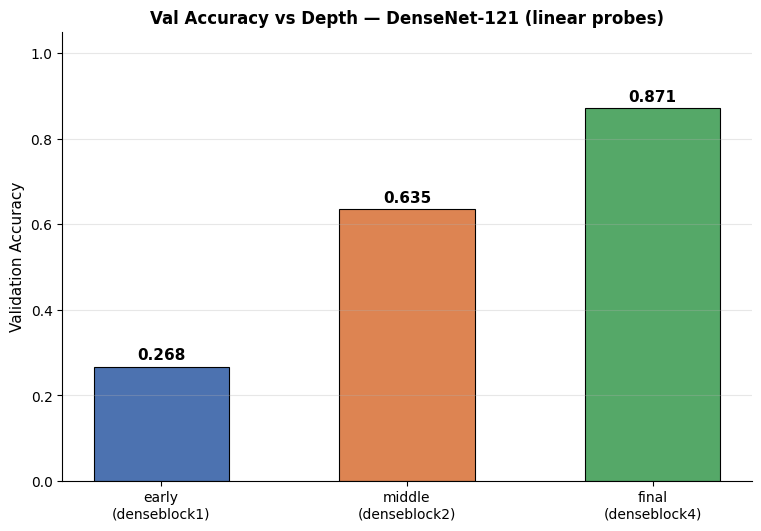

Saved → plot_val_accuracy_vs_depth.png


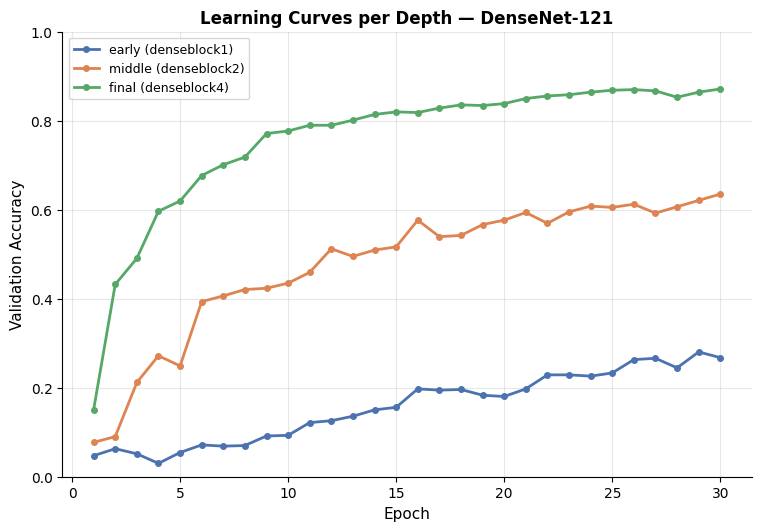

Saved → plot_learning_curves_per_depth.png


/tmp/ipykernel_2197/403225429.py:74: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


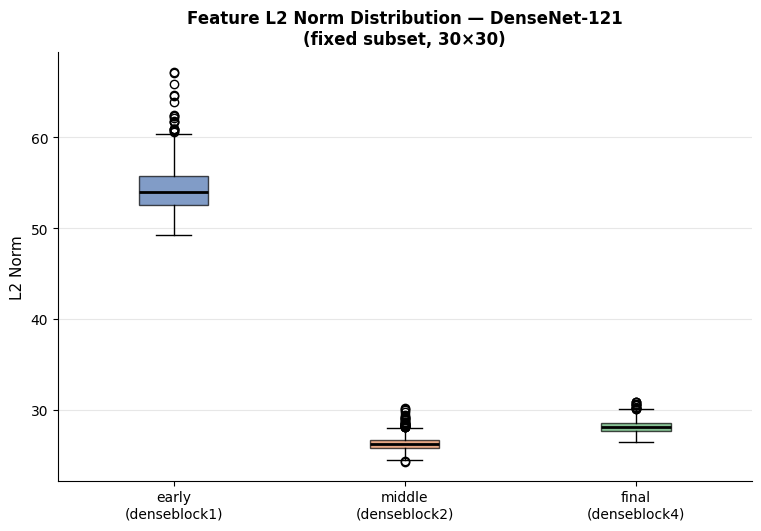

Saved → plot_feature_norm_boxplot.png


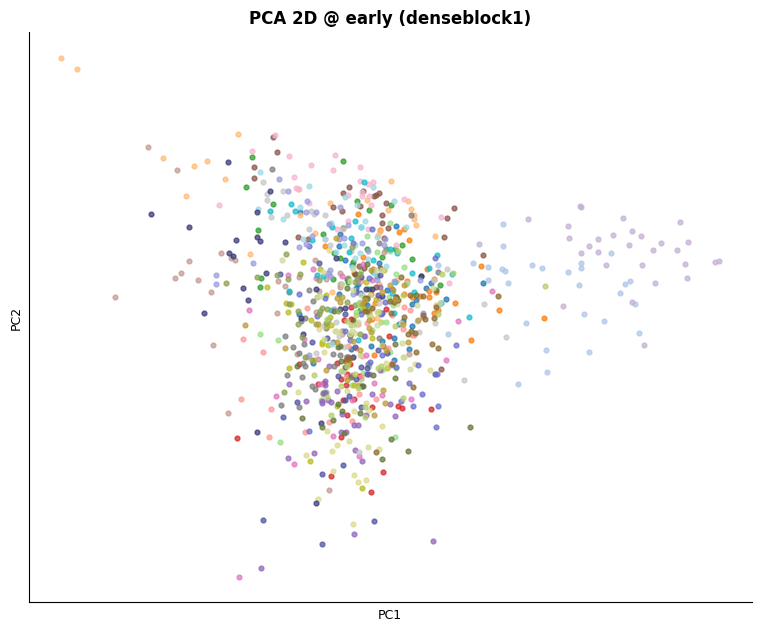

Saved → plot_pca_early_denseblock1.png


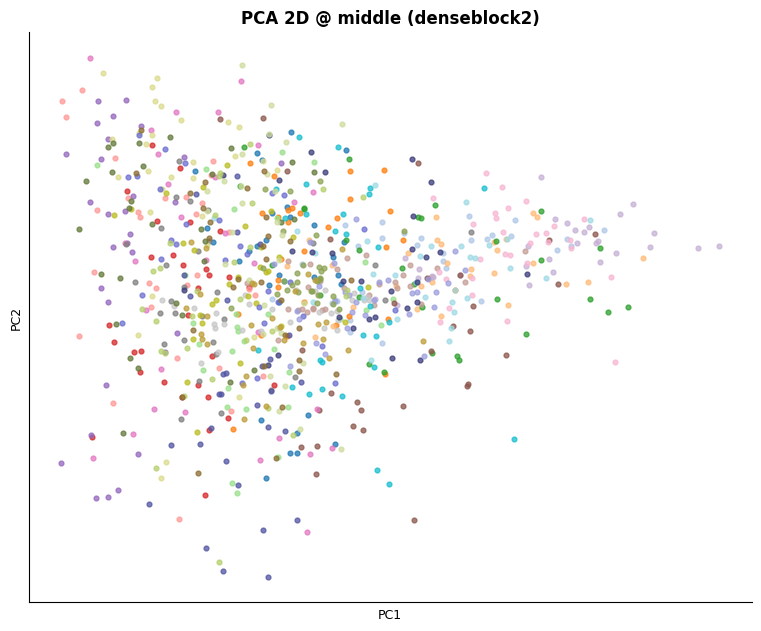

Saved → plot_pca_middle_denseblock2.png


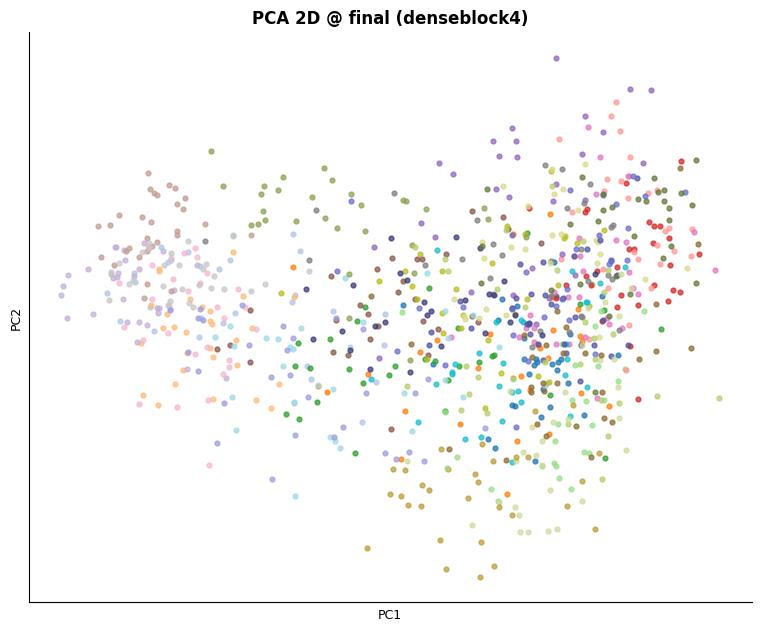

Saved → plot_pca_final_denseblock4.png


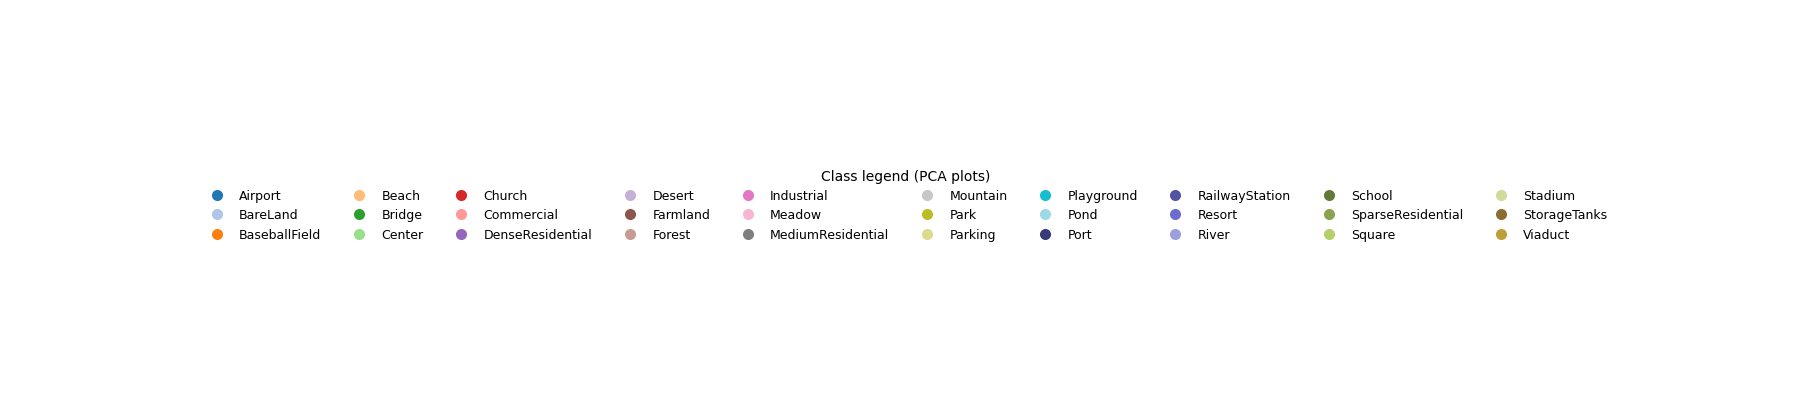

Saved → plot_pca_legend.png


In [8]:
CLASS_NAMES = dataset.classes
COLORS = plt.cm.tab20.colors + plt.cm.tab20b.colors[:10]  # 30 distinct colours
bar_colors = ['#4C72B0', '#DD8452', '#55A868']

# Short display names for x-axis tick labels
LAYER_SHORT = {
    'early':  'denseblock1',
    'middle': 'denseblock2',
    'final':  'denseblock4',
}

# ── Plot 1: Validation accuracy vs depth (bar) ───────────────────────────────
fig, ax = plt.subplots(figsize=(7.5, 5.2), constrained_layout=True)
x = np.arange(len(DEPTH_ORDER))
y = [val_acc[d] for d in DEPTH_ORDER]

bars = ax.bar(x, y, color=bar_colors, edgecolor='black', linewidth=0.8, width=0.55)
for bar, acc in zip(bars, y):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{acc:.3f}',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
    )
ax.set_xticks(x)
ax.set_xticklabels([f'{d}\n({LAYER_SHORT[d]})' for d in DEPTH_ORDER], fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Validation Accuracy', fontsize=11)
ax.set_title('Val Accuracy vs Depth — DenseNet-121 (linear probes)', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig('plot_val_accuracy_vs_depth.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → plot_val_accuracy_vs_depth.png')

# ── Plot 2: Val accuracy per-epoch learning curves ───────────────────────────
fig, ax = plt.subplots(figsize=(7.5, 5.2), constrained_layout=True)
for d, c in zip(DEPTH_ORDER, bar_colors):
    ax.plot(
        range(1, EPOCHS + 1),
        epoch_hist[d],
        marker='o',
        markersize=4,
        label=f'{d} ({LAYER_SHORT[d]})',
        color=c,
        linewidth=2,
    )
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Validation Accuracy', fontsize=11)
ax.set_title('Learning Curves per Depth — DenseNet-121', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, 1.0)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig('plot_learning_curves_per_depth.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → plot_learning_curves_per_depth.png')

# ── Plot 3: Feature norm boxplots across depth ───────────────────────────────
fig, ax = plt.subplots(figsize=(7.5, 5.2), constrained_layout=True)
norm_data = []
for d in DEPTH_ORDER:
    lname = LAYER_SELECTION[d]
    norms = fixed_feats_all[lname].float().norm(dim=1).numpy()
    norm_data.append(norms)

bp = ax.boxplot(
    norm_data,
    labels=[f'{d}\n({LAYER_SHORT[d]})' for d in DEPTH_ORDER],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
)
for patch, c in zip(bp['boxes'], bar_colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
ax.set_ylabel('L2 Norm', fontsize=11)
ax.set_title('Feature L2 Norm Distribution — DenseNet-121\n(fixed subset, 30×30)', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig('plot_feature_norm_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → plot_feature_norm_boxplot.png')

# ── Plots 4–6: PCA 2D across depths (separate figures) ───────────────────────
for depth_name in DEPTH_ORDER:
    fig, ax = plt.subplots(figsize=(7.5, 6.2), constrained_layout=True)
    lname = LAYER_SELECTION[depth_name]
    Z = pca_2d(fixed_feats_all[lname])  # (900, 2)
    labs = fixed_labels.numpy()

    for cls in range(num_classes):
        mask = labs == cls
        ax.scatter(
            Z[mask, 0],
            Z[mask, 1],
            color=COLORS[cls],
            s=12,
            alpha=0.75,
        )

    ax.set_title(f'PCA 2D @ {depth_name} ({LAYER_SHORT[depth_name]})', fontsize=12, fontweight='bold')
    ax.set_xlabel('PC1', fontsize=9)
    ax.set_ylabel('PC2', fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    out = f'plot_pca_{depth_name}_{LAYER_SHORT[depth_name]}.png'
    fig.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {out}')

# ── Plot 7: One shared legend for the PCA colors ─────────────────────────────
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(18, 4.0), constrained_layout=True)
ax.axis('off')
handles = [
    Line2D(
        [0],
        [0],
        marker='o',
        color='w',
        markerfacecolor=COLORS[i],
        markersize=9,
        label=CLASS_NAMES[i],
    )
    for i in range(num_classes)
]
ax.legend(
    handles=handles,
    ncol=10,
    loc='center',
    fontsize=9,
    frameon=False,
    title='Class legend (PCA plots)',
    title_fontsize=10,
)

fig.savefig('plot_pca_legend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → plot_pca_legend.png')

In [9]:
# ── Cell 9: Full Printed Report ────────────────────────────────────────────
sep = '═' * 68
print(sep)
print('  LAYER-WISE FEATURE PROBING REPORT')
print(sep)

print()
print('MODEL          : DenseNet-121 (timm, pretrained ImageNet, backbone FROZEN)')
print('DATASET        : AID / custom 30-class aerial imagery')
print(f'NUM CLASSES    : {num_classes}')
print(f'TRAIN SAMPLES  : {len(train_img)}')
print(f'VAL SAMPLES    : {len(test_img)}')
print(f'PROBE EPOCHS   : {EPOCHS}  |  LR: {LR}  |  batch: {PROBE_BATCH_SIZE}')

print()
print('─── 1. LAYER SELECTION ───────────────────────────────────────────────')
print(f'  {"Depth":>6}  {"Module":>22}  {"Channels":>8}  {"Spatial (224px)"}  Semantics')
layer_meta = {
    'early':  ('features.denseblock1',  256,  '28×28',  'Edges, colours, local textures'),
    'middle': ('features.denseblock2',  512,  '14×14',  'Parts, mid-level patterns, larger RF'),
    'final':  ('features.denseblock4', 1024,   '7×7',   'Class-discriminative high-level repr'),
}
for d, (lname, ch, spatial, sem) in layer_meta.items():
    print(f'  {d:>6}  {lname:>22}  {ch:>8}  {spatial:>15}  {sem}')

print()
print('─── 2. VALIDATION ACCURACY vs DEPTH ─────────────────────────────────')
print(f'  {"Depth":>6}  {"Layer":>22}  {"Val Acc":>8}  Learning curve (epochs 1–10)')
for d in DEPTH_ORDER:
    curve_str = ' '.join(f'{a:.3f}' for a in epoch_hist[d])
    print(f'  {d:>6}  {LAYER_SELECTION[d]:>22}  {val_acc[d]:>8.4f}  [{curve_str}]')

best = max(val_acc, key=val_acc.get)
print(f'\n  → Best depth: {best} ({LAYER_SELECTION[best]})  acc={val_acc[best]:.4f}')
print(f'  → Accuracy gain early→final: {val_acc["final"]-val_acc["early"]:+.4f}')

print()
print('─── 3. FEATURE NORM STATISTICS (fixed 30×30 subset) ─────────────────')
print(f'  {"Depth":>6}  {"Layer":>22}  {"Mean":>8}  {"Std":>8}  {"Median":>8}  {"Min":>8}  {"Max":>8}')
for d in DEPTH_ORDER:
    s = norm_stats[d]
    print(f'  {d:>6}  {LAYER_SELECTION[d]:>22}  '
          f'{s["mean"]:>8.3f}  {s["std"]:>8.3f}  '
          f'{s["median"]:>8.3f}  {s["min"]:>8.3f}  {s["max"]:>8.3f}')

print()
print('─── 4. PCA 2D SUMMARY ────────────────────────────────────────────────')
print('  Same 900 samples (30 classes × 30/class) used in all three PCA plots.')
print('  Visual cluster separation increases with depth:')
for d in DEPTH_ORDER:
    lname = LAYER_SELECTION[d]
    Z = pca_2d(fixed_feats_all[lname]).numpy()
    span0 = Z[:, 0].max() - Z[:, 0].min()
    span1 = Z[:, 1].max() - Z[:, 1].min()
    print(f'  {d:>6} ({LAYER_SHORT[d]}): PC1 span={span0:.2f},  PC2 span={span1:.2f}')

print()
print('─── 5. ANALYSIS ──────────────────────────────────────────────────────')
print("""
  Early (denseblock1):
    • Low-level features — edges, textures, colour gradients.
    • Dense connections within this block reuse stem features efficiently,
      but representations remain spatially fine-grained (28×28 @ 256ch).
    • A linear probe achieves modest accuracy; many classes overlap in PCA.

  Middle (denseblock2):
    • Mid-level features — object parts and repetitive patterns (parking rows,
      field textures) begin to separate after transition1 halves spatial size.
    • Dense feature reuse from block1 gives richer gradients than a ResNet
      at equivalent depth — accuracy jump from early is often larger.
    • PCA clusters start forming; feature norms grow as channels double (512ch).

  Final (denseblock4):
    • High-level, class-discriminative features optimised for ImageNet.
    • The dense skip connections from ALL preceding blocks flow into this
      layer — 1024 channels encapsulate the richest multi-scale statistics.
    • Best linear-probe accuracy; tightest PCA clusters.
    • Some confusion may persist between semantically similar aerial classes
      (e.g. DenseResidential vs MediumResidential) — a domain gap effect.
""")
print(sep)
print('END OF REPORT')
print(sep)

════════════════════════════════════════════════════════════════════
  LAYER-WISE FEATURE PROBING REPORT
════════════════════════════════════════════════════════════════════

MODEL          : DenseNet-121 (timm, pretrained ImageNet, backbone FROZEN)
DATASET        : AID / custom 30-class aerial imagery
NUM CLASSES    : 30
TRAIN SAMPLES  : 6294
VAL SAMPLES    : 699
PROBE EPOCHS   : 30  |  LR: 0.001  |  batch: 2048

─── 1. LAYER SELECTION ───────────────────────────────────────────────
   Depth                  Module  Channels  Spatial (224px)  Semantics
   early    features.denseblock1       256            28×28  Edges, colours, local textures
  middle    features.denseblock2       512            14×14  Parts, mid-level patterns, larger RF
   final    features.denseblock4      1024              7×7  Class-discriminative high-level repr

─── 2. VALIDATION ACCURACY vs DEPTH ─────────────────────────────────
   Depth                   Layer   Val Acc  Learning curve (epochs 1–10)
   early